In [2]:
from datasets import load_dataset

dataset = load_dataset("stanfordnlp/imdb")

print(dataset)

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

c:\Users\audrb\miniconda3\envs\ml_portfolio\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\audrb\.cache\huggingface\hub\datasets--stanfordnlp--imdb. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

...

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [ ]:
for i in range(10):
    print("TEXT:")
    print(dataset["train"][i]["text"][:300])

    print("LABEL:")
    print(dataset["train"][i]["label"])

    print("=" * 50)

In [9]:
train_dataset = dataset["train"].shuffle(seed=42).select(range(10000))
test_dataset = dataset["test"].shuffle(seed=42).select(range(2000))

In [10]:
split_dataset = train_dataset.train_test_split(
    test_size=0.2,
    seed=42
)

train_dataset = split_dataset["train"]
val_dataset = split_dataset["test"]

In [11]:
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 8000
Validation: 2000
Test: 2000


In [12]:
def tokenize(text):
    return text.lower().split()

In [13]:
sentence = "This movie was really good"

print(tokenize(sentence))

['this', 'movie', 'was', 'really', 'good']


In [14]:
from collections import Counter

counter = Counter()

for example in train_dataset:
    tokens = tokenize(example["text"])
    counter.update(tokens)

In [15]:
print(counter.most_common(20))

[('the', 102352), ('a', 50842), ('and', 49990), ('of', 45735), ('to', 42673), ('is', 33342), ('in', 28787), ('i', 22402), ('this', 21946), ('that', 21353), ('it', 20950), ('/><br', 16218), ('was', 15341), ('as', 14643), ('for', 13603), ('with', 13508), ('but', 12827), ('on', 9992), ('movie', 9848), ('not', 9276)]


In [16]:
max_vocab_size = 20000

most_common_words = counter.most_common(max_vocab_size - 2)

In [20]:
print(most_common_words[:10])

[('the', 102352), ('a', 50842), ('and', 49990), ('of', 45735), ('to', 42673), ('is', 33342), ('in', 28787), ('i', 22402), ('this', 21946), ('that', 21353)]


In [17]:
vocab = {
    "<PAD>": 0,
    "<UNK>": 1
}

for word, _ in most_common_words:
    vocab[word] = len(vocab)

In [18]:
print("Vocabulary size:", len(vocab))

print(vocab["movie"])
print(vocab["good"])

Vocabulary size: 20000
20
56


In [21]:
MAX_LENGTH = 200

def encode_text(text):
    tokens = tokenize(text)

    encoded = [
        vocab.get(token, vocab["<UNK>"])
        for token in tokens
    ]

    encoded = encoded[:MAX_LENGTH]

    return encoded

In [22]:
import torch
from torch.utils.data import Dataset

class IMDBDataset(Dataset):

    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        text = self.dataset[idx]["text"]
        label = self.dataset[idx]["label"]

        encoded_text = encode_text(text)

        return {
            "text": torch.tensor(encoded_text, dtype=torch.long),
            "label": torch.tensor(label, dtype=torch.long)
        }

In [23]:
train_data = IMDBDataset(train_dataset)
val_data = IMDBDataset(val_dataset)
test_data = IMDBDataset(test_dataset)

In [24]:
print(len(train_data))
print(train_data[0])

8000
{'text': tensor([    9,   371, 12826,     8,  1226, 14146,     4,     9,  3139,  2932,
           62,   683,    80,   458,    10,    20,    73,  1801,   608,    30,
          219,    74,     6,    65,   102,  2474,    46, 10868,  2876,  1515,
           10,     7,     3,  3479,  5792,  1440,     5,  1441, 10093,     1,
            1,     4,  7123,     1,    51,    22,   156,   245,   152,     5,
           91,  7124,    55, 11729,  1527,  1822,   955,     4,     2,   156,
           11,    22,    22,   362,     4,  2708,    38,   791,    11,    25,
          177,    55,    89,    47,    48,     8,     2,   238,     7,   155,
          781,     2,  6525,     7,    83, 10094,     4,   395,     2, 15858,
           11,     7,    10,    20,     7,   117,  8340,    31,     2,   234,
           11,    12,  1456,   883,     2,  1152,     1,   508,   426,    34,
            1,   826,    37,     2,     1,    54,    65,   137,  1527,  1822,
           31,   268,   134,     2,  2507,     5, 

In [30]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    texts = [item["text"] for item in batch]
    labels = [item["label"] for item in batch]

    lengths = torch.tensor(
        [len(text) for text in texts],
        dtype=torch.long
    )

    texts = pad_sequence(
        texts,
        batch_first=True,
        padding_value=vocab["<PAD>"]
    )

    labels = torch.stack(labels)

    return texts, lengths, labels

In [31]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_data,
    batch_size=64,
    shuffle=False,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=False,
    collate_fn=collate_fn
)

In [35]:
texts,lengths, labels = next(iter(train_loader))

print(texts.shape)
print(labels.shape)
print(lengths)

torch.Size([64, 200])
torch.Size([64])
tensor([108, 200, 200, 200, 122, 200, 200, 200, 169, 200, 145,  67,  70, 200,
        129, 145, 200, 120, 155, 200,  64, 156, 124, 200, 200, 200, 147, 200,
        157, 113,  92, 200, 113, 200, 153, 131, 117, 200, 138, 187, 159, 187,
        200, 200,  57, 200, 195, 200, 195, 181, 200,  83, 200, 125, 159, 200,
        182, 175,  95, 200, 200, 200, 131, 133])


In [48]:
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence

class LSTMClassifier(nn.Module):

    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_dim,
            2
        )

    def forward(self, x, lengths):

        embedded = self.embedding(x)

        packed = pack_padded_sequence(
        embedded,
        lengths.cpu(),
        batch_first=True,
        enforce_sorted=False
        )

        output, (hidden, cell) = self.lstm(packed)

        last_hidden = hidden[-1]

        logits = self.fc(last_hidden)

        return logits

In [49]:
vocab_size = len(vocab)
embedding_dim = 128
hidden_dim = 128

model = LSTMClassifier(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim
)

In [50]:
criterion = nn.CrossEntropyLoss()

In [51]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [53]:
num_epochs = 5

for epoch in range(num_epochs):

    model.train()

    total_loss = 0
    total_correct = 0
    total_samples = 0

    for texts, lengths, labels in train_loader:

        optimizer.zero_grad()

        logits = model(texts, lengths)

        loss = criterion(logits, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        predictions = logits.argmax(dim=1)

        total_correct += (predictions == labels).sum().item()

        total_samples += labels.size(0)

    avg_loss = total_loss / len(train_loader)

    accuracy = total_correct / total_samples

    print(
        f"Epoch {epoch+1}/{num_epochs} "
        f"Loss: {avg_loss:.4f} "
        f"Accuracy: {accuracy:.4f}"
    )

Epoch 1/5 Loss: 0.6790 Accuracy: 0.5559
Epoch 2/5 Loss: 0.6334 Accuracy: 0.6474
Epoch 3/5 Loss: 0.5238 Accuracy: 0.7441
Epoch 4/5 Loss: 0.4010 Accuracy: 0.8235
Epoch 5/5 Loss: 0.3100 Accuracy: 0.8739


In [54]:
model.eval()

val_loss = 0
val_correct = 0
val_samples = 0

with torch.no_grad():

    for texts, lengths, labels in val_loader:

        logits = model(texts, lengths)

        loss = criterion(logits, labels)

        val_loss += loss.item()

        predictions = logits.argmax(dim=1)

        val_correct += (predictions == labels).sum().item()

        val_samples += labels.size(0)

avg_val_loss = val_loss / len(val_loader)
val_accuracy = val_correct / val_samples

print(f"Validation Loss: {avg_val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

Validation Loss: 0.5620
Validation Accuracy: 0.7390


In [55]:
class LSTMDropoutClassifier(nn.Module):

    def __init__(self, vocab_size, embedding_dim, hidden_dim, dropout=0.5):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=vocab["<PAD>"]
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(
            hidden_dim,
            2
        )

    def forward(self, x, lengths):

        embedded = self.embedding(x)

        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        output, (hidden, cell) = self.lstm(packed)

        last_hidden = hidden[-1]

        last_hidden = self.dropout(last_hidden)

        logits = self.fc(last_hidden)

        return logits

In [56]:
dropout_model = LSTMDropoutClassifier(
    vocab_size=len(vocab),
    embedding_dim=128,
    hidden_dim=128,
    dropout=0.5
)

In [57]:
criterion = nn.CrossEntropyLoss()

dropout_optimizer = torch.optim.Adam(
    dropout_model.parameters(),
    lr=0.001
)

In [58]:
def train_model(model, optimizer, train_loader, val_loader, criterion, num_epochs=5):

    train_losses = []
    train_accuracies = []

    val_losses = []
    val_accuracies = []

    for epoch in range(num_epochs):

        # =========================
        # 1. Train
        # =========================
        model.train()

        total_loss = 0
        total_correct = 0
        total_samples = 0

        for texts, lengths, labels in train_loader:

            optimizer.zero_grad()

            logits = model(texts, lengths)

            loss = criterion(logits, labels)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

            predictions = logits.argmax(dim=1)

            total_correct += (predictions == labels).sum().item()
            total_samples += labels.size(0)

        train_loss = total_loss / len(train_loader)
        train_accuracy = total_correct / total_samples


        # =========================
        # 2. Validation
        # =========================
        model.eval()

        val_total_loss = 0
        val_total_correct = 0
        val_total_samples = 0

        with torch.no_grad():

            for texts, lengths, labels in val_loader:

                logits = model(texts, lengths)

                loss = criterion(logits, labels)

                val_total_loss += loss.item()

                predictions = logits.argmax(dim=1)

                val_total_correct += (predictions == labels).sum().item()
                val_total_samples += labels.size(0)

        val_loss = val_total_loss / len(val_loader)
        val_accuracy = val_total_correct / val_total_samples


        # =========================
        # 3. 결과 저장
        # =========================
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)

        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)


        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )

    return (
        train_losses,
        train_accuracies,
        val_losses,
        val_accuracies
    )

In [59]:
baseline_model = LSTMClassifier(
    vocab_size=len(vocab),
    embedding_dim=128,
    hidden_dim=128
)

baseline_optimizer = torch.optim.Adam(
    baseline_model.parameters(),
    lr=0.001
)

In [60]:
baseline_results = train_model(
    baseline_model,
    baseline_optimizer,
    train_loader,
    val_loader,
    criterion,
    num_epochs=5
)

Epoch 1/5 | Train Loss: 0.6854 | Train Acc: 0.5421 | Val Loss: 0.6441 | Val Acc: 0.6300
Epoch 2/5 | Train Loss: 0.5994 | Train Acc: 0.6791 | Val Loss: 0.6241 | Val Acc: 0.6725
Epoch 3/5 | Train Loss: 0.4962 | Train Acc: 0.7630 | Val Loss: 0.5606 | Val Acc: 0.7265
Epoch 4/5 | Train Loss: 0.4009 | Train Acc: 0.8250 | Val Loss: 0.5625 | Val Acc: 0.7420
Epoch 5/5 | Train Loss: 0.3170 | Train Acc: 0.8686 | Val Loss: 0.6165 | Val Acc: 0.7125


In [61]:
dropout_model = LSTMDropoutClassifier(
    vocab_size=len(vocab),
    embedding_dim=128,
    hidden_dim=128,
    dropout=0.5
)

dropout_optimizer = torch.optim.Adam(
    dropout_model.parameters(),
    lr=0.001
)

In [62]:
dropout_results = train_model(
    dropout_model,
    dropout_optimizer,
    train_loader,
    val_loader,
    criterion,
    num_epochs=5
)

Epoch 1/5 | Train Loss: 0.6857 | Train Acc: 0.5423 | Val Loss: 0.6575 | Val Acc: 0.5935
Epoch 2/5 | Train Loss: 0.6254 | Train Acc: 0.6465 | Val Loss: 0.6158 | Val Acc: 0.6720
Epoch 3/5 | Train Loss: 0.5436 | Train Acc: 0.7326 | Val Loss: 0.6030 | Val Acc: 0.6810
Epoch 4/5 | Train Loss: 0.4334 | Train Acc: 0.8050 | Val Loss: 0.5601 | Val Acc: 0.7030
Epoch 5/5 | Train Loss: 0.4051 | Train Acc: 0.8281 | Val Loss: 0.6707 | Val Acc: 0.7110


In [63]:
def train_earlystop_model(
    model,
    optimizer,
    train_loader,
    val_loader,
    criterion,
    num_epochs=10,
    patience=2,
    model_path="best_model.pt"
):

    train_losses = []
    train_accuracies = []

    val_losses = []
    val_accuracies = []

    best_val_loss = float("inf")
    patience_counter = 0

    for epoch in range(num_epochs):

        # =========================
        # Train
        # =========================
        model.train()

        total_loss = 0
        total_correct = 0
        total_samples = 0

        for texts, lengths, labels in train_loader:

            optimizer.zero_grad()

            logits = model(texts, lengths)

            loss = criterion(logits, labels)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

            predictions = logits.argmax(dim=1)

            total_correct += (predictions == labels).sum().item()
            total_samples += labels.size(0)

        train_loss = total_loss / len(train_loader)
        train_accuracy = total_correct / total_samples


        # =========================
        # Validation
        # =========================
        model.eval()

        val_total_loss = 0
        val_total_correct = 0
        val_total_samples = 0

        with torch.no_grad():

            for texts, lengths, labels in val_loader:

                logits = model(texts, lengths)

                loss = criterion(logits, labels)

                val_total_loss += loss.item()

                predictions = logits.argmax(dim=1)

                val_total_correct += (predictions == labels).sum().item()
                val_total_samples += labels.size(0)

        val_loss = val_total_loss / len(val_loader)
        val_accuracy = val_total_correct / val_total_samples


        # =========================
        # 결과 저장
        # =========================
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)

        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )


        # =========================
        # Early Stopping
        # =========================
        if val_loss < best_val_loss:

            best_val_loss = val_loss
            patience_counter = 0

            torch.save(
                model.state_dict(),
                model_path
            )

            print("Best model saved!")

        else:

            patience_counter += 1

            print(
                f"No improvement "
                f"({patience_counter}/{patience})"
            )

            if patience_counter >= patience:

                print("Early stopping!")
                break


    return (
        train_losses,
        train_accuracies,
        val_losses,
        val_accuracies
    )

In [64]:
earlystop_dropout_model = LSTMDropoutClassifier(
    vocab_size=len(vocab),
    embedding_dim=128,
    hidden_dim=128,
    dropout=0.5
)

earlystop_dropout_optimizer = torch.optim.Adam(
    earlystop_dropout_model.parameters(),
    lr=0.001
)

In [67]:
earlystop_dropout_results = train_earlystop_model(
    earlystop_dropout_model,
    earlystop_dropout_optimizer,
    train_loader,
    val_loader,
    criterion,
    num_epochs=10,
    patience=2,
    model_path="best_earlystop_dropout_lstm.pt"
)

Epoch 1/10 | Train Loss: 0.4449 | Train Acc: 0.8017 | Val Loss: 0.6065 | Val Acc: 0.7360
Best model saved!
Epoch 2/10 | Train Loss: 0.3410 | Train Acc: 0.8578 | Val Loss: 0.5645 | Val Acc: 0.7550
Best model saved!
Epoch 3/10 | Train Loss: 0.2595 | Train Acc: 0.8992 | Val Loss: 0.6485 | Val Acc: 0.7475
No improvement (1/2)
Epoch 4/10 | Train Loss: 0.1548 | Train Acc: 0.9464 | Val Loss: 0.7453 | Val Acc: 0.7710
No improvement (2/2)
Early stopping!


In [68]:
earlystop_dropout_model.load_state_dict(
    torch.load("best_earlystop_dropout_lstm.pt")
)

<All keys matched successfully>

In [69]:
earlystop_dropout_model.eval()

test_loss = 0
test_correct = 0
test_samples = 0

with torch.no_grad():

    for texts, lengths, labels in test_loader:

        logits = earlystop_dropout_model(texts, lengths)

        loss = criterion(logits, labels)

        test_loss += loss.item()

        predictions = logits.argmax(dim=1)

        test_correct += (predictions == labels).sum().item()

        test_samples += labels.size(0)

avg_test_loss = test_loss / len(test_loader)
test_accuracy = test_correct / test_samples

print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.6001
Test Accuracy: 0.7390


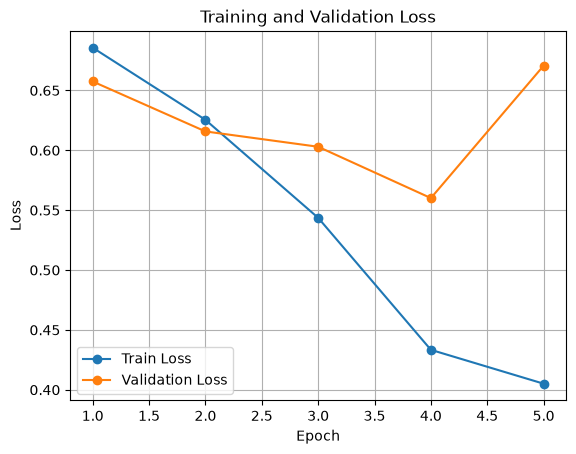

In [83]:
import matplotlib.pyplot as plt
import os

os.makedirs("results", exist_ok=True)

train_losses, train_accuracies, val_losses, val_accuracies = dropout_results

epochs = range(1, len(train_losses) + 1)

plt.figure()

plt.plot(epochs, train_losses, marker="o", label="Train Loss")
plt.plot(epochs, val_losses, marker="o", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.savefig(
    "results/loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

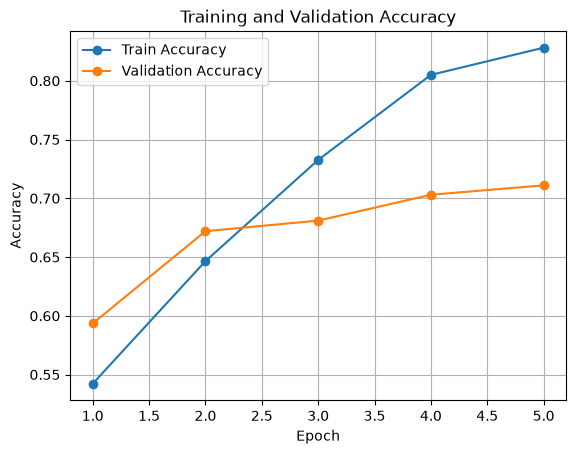

In [84]:
plt.figure()

plt.plot(epochs, train_accuracies, marker="o", label="Train Accuracy")
plt.plot(epochs, val_accuracies, marker="o", label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()
plt.savefig(
    "results/accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

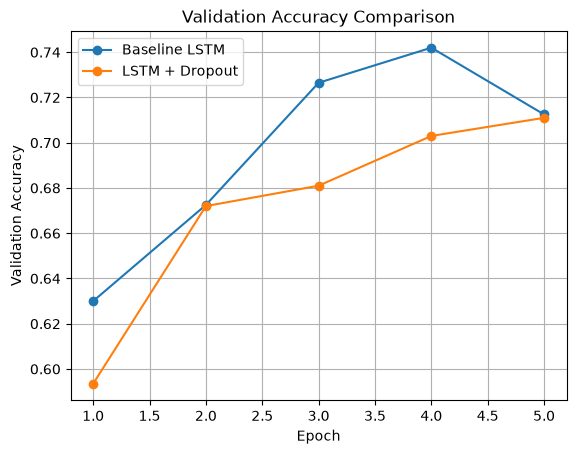

In [85]:
import matplotlib.pyplot as plt

baseline_train_losses, baseline_train_accs, baseline_val_losses, baseline_val_accs = baseline_results

dropout_train_losses, dropout_train_accs, dropout_val_losses, dropout_val_accs = dropout_results

epochs = range(1, len(baseline_val_accs) + 1)

plt.figure()

plt.plot(
    epochs,
    baseline_val_accs,
    marker="o",
    label="Baseline LSTM"
)

plt.plot(
    epochs,
    dropout_val_accs,
    marker="o",
    label="LSTM + Dropout"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.grid()
plt.savefig(
    "results/BaseLine_Dropout.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()